# Project 4: Linear Regression from Scratch

Implement linear regression using gradient
descent (not scikit-learn). Train it on a real
dataset from UCI ML Repository — the Energy
Efficiency dataset. Plot the loss curve across
epochs. Compare your from-scratch results to
NumPy's polyfit. Report the final MSE and R²
score.

### Skills: Gradient descent, MSE loss, R² metric, UCI dataset loading

SCRATCH MODEL: MSE = 8.6431, R² = 0.9150


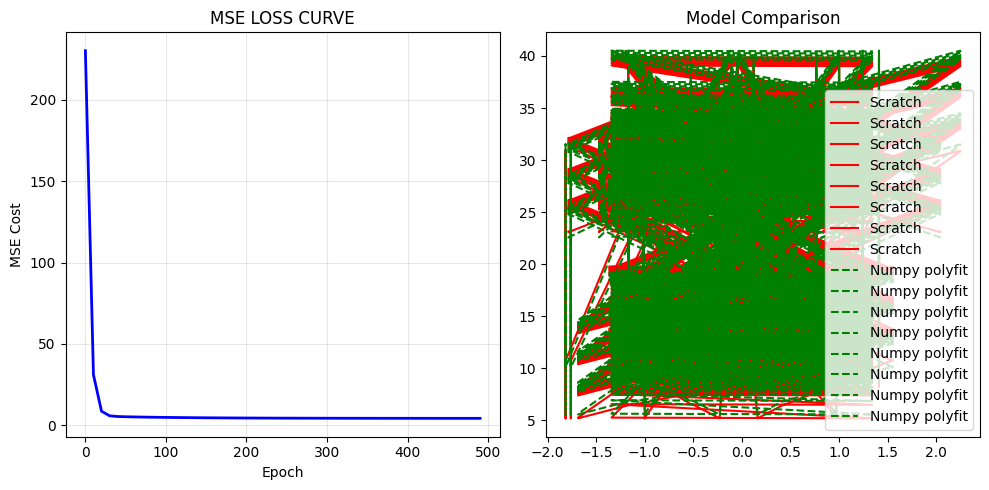

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. DATA PREPARATION ---
def load_and_preprocess():
    # URL for Energy Efficiency dataset
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
    df = pd.read_excel(url)
    # A common mirror of the Energy Efficiency dataset in CSV format
    # url_csv = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/energy_efficiency.csv"
    # df = pd.read_csv(url_csv)
    
    # X: Features (first 8 columns), y: Heating Load (9th column)
    X = df.iloc[:, :8].values
    y = df.iloc[:, 8].values.reshape(-1, 1)
    
    # Feature Scaling (Z-score Normalization)
    # This ensures the gradient for each weight is on the same scale
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_scaled = (X - X_mean) / X_std
    
    return X_scaled, y

# --- 2. THE CORE ENGINE ---
def compute_cost(X, y, W, b):
    """Computes Mean Squared Error: J = (1/2n) * Σ(pred - y)^2"""
    n = len(y)
    predictions = X @ W + b  # Matrix multiplication
    cost = (1 / (2 * n)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, lr=0.05, epochs=1000):
    n_samples, n_features = X.shape
    
    # Initialize weights to zeros and bias to zero
    W = np.zeros((n_features, 1))
    b = 0.0
    
    cost_history = []
    
    for epoch in range(epochs):
        # 1. Prediction (Hypothesis)
        y_hat = X @ W + b
        
        # 2. Gradient Calculation (The partial derivatives)
        # dJ/dW = (1/n) * X.T * (y_hat - y)
        error = y_hat - y
        dW = (1 / n_samples) * (X.T @ error)
        db = (1 / n_samples) * np.sum(error)
        
        # 3. Parameter Update
        W = W - lr * dW
        b = b - lr * db
        
        # Track progress
        if epoch % 10 == 0:
            cost_history.append(compute_cost(X, y, W, b))
            
    return W, b, cost_history

# --- 3. METRICS AND COMPARISON ---
def evaluate_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    
    # R² = 1 - (SS_res / SS_tot)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return mse, r2

# --- 4. EXECUTION ---
X, y = load_and_preprocess()
W, b, history = gradient_descent(X, y, lr=0.1, epochs=500)

# 1. Predictions from our scratch model
y_pred_scratch = X @ W + b

# 2. Predictions using NumPy polyfit (Least Squares baseline)
# polyfit works on 1D, so we flatten X to its most correlated feature for baseline
# or use np.linalg.lstsq for a true multi-variate comparison
# Here we use the Normal Equation (LSTSQ) as the professional "Numpy way"
X_bias = np.c_[np.ones(X.shape[0]), X] # Add intercept column
W_numpy, _, _, _ = np.linalg.lstsq(X_bias, y, rcond=None)
y_pred_numpy = X_bias @ W_numpy

# --- 5. RESULTS ---
mse_s, r2_s = evaluate_metrics(y, y_pred_scratch)
print(f"SCRATCH MODEL: MSE = {mse_s:.4f}, R² = {r2_s:.4f}")

# --- 6. PLOTTING ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(0, 500, 10), history, color='blue', lw=2)
plt.title("MSE LOSS CURVE")
plt.xlabel("Epoch")
plt.ylabel("MSE Cost")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# plt.scatter(X, y, alpha=0.3, label="Actual Data")
plt.plot(X, y_pred_scratch, color ='red', label="Scratch")
plt.plot(X, y_pred_numpy, '--', color= 'green', label="Numpy polyfit")
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()